# 07 · Intégration : croiser plusieurs sources

Synthèse du TP : relier une base **document** (MongoDB), une base **relationnelle** (PostgreSQL) et une **API web** (Banque mondiale) dans un seul tableau fiable, livré en fichier Parquet et dans une petite base analytique DuckDB.

> 🎯 **Cas d'usage**
>
> Votre groupe possède deux activités : une **application de VTC, de livraison et de location**, présente dans 19 pays africains (données dans MongoDB), et un **réseau d'écoles** au Bénin, au Sénégal et en France (données dans PostgreSQL). Le comité de direction prépare son plan d'expansion et veut **un seul tableau, avec une ligne par pays**, qui croise :
> - l'activité de l'application : nombre de **courses** et d'**utilisateurs** ;
> - le nombre d'**élèves** du réseau scolaire ;
> - la **population** du pays (API de la Banque mondiale).
>
> Indicateur phare : les **courses pour 100 000 habitants**, pour comparer des pays de tailles très différentes. Livrables : un fichier **Parquet « gold »** pour le tableau de bord, et une base **DuckDB** que l'on pourra recharger chaque mois **sans créer de doublons**.

**Ce que vous allez apprendre**
- enchaîner les trois étapes d'un pipeline **ELT** (Extraire → Charger → Transformer) et ranger les tables en couches **bronze / gold** ;
- extraire un petit résumé de trois sources très différentes, en laissant chaque source faire le calcul ;
- choisir une **clé de jointure** fiable (le code ISO du pays) plutôt qu'un nom ;
- utiliser une **jointure externe** et interpréter les valeurs manquantes ;
- charger de façon **idempotente** dans DuckDB (relancer donne le même résultat) ;
- **contrôler la qualité** (unicité, complétude, réconciliation, fraîcheur) avant de livrer.

**Durée indicative** : 15 min pour exécuter et lire les sections 1 à 8 (synthèse / bonus), puis 15 à 20 min d'exercices, à finir en autonomie si besoin. L'exécution complète prend environ 15 secondes (jusqu'à une minute si l'API de la Banque mondiale est lente).

**Prérequis** : avoir vu les notebooks 02 (PostgreSQL), 03 (MongoDB) et 05 (API REST) ; le fichier `.env` rempli à la racine du dépôt ; les dépendances installées (`uv sync`) ; des notions de SQL (`JOIN`, `GROUP BY`).

> ⚠️ **Bases partagées, en lecture seule.** On ne fait que des **lectures** sur PostgreSQL et MongoDB (aucune écriture). Toutes les écritures de ce notebook se font **chez vous** : dans le fichier DuckDB et dans le dossier `data/`.

## 1. Le principe : un pipeline ELT en couches

Rappel du cours :
- **ETL** (*Extract, Transform, Load*) : on transforme les données **avant** de les charger dans l'entrepôt ;
- **ELT** (*Extract, Load, Transform*) : on **charge d'abord** les données telles quelles dans l'entrepôt, puis on les **transforme avec SQL** à l'intérieur. C'est l'approche moderne : la donnée brute reste disponible, et on peut refaire les calculs à tout moment.

Ici, l'« entrepôt » est **DuckDB** : une base **analytique** (OLAP) qui tient dans un simple fichier, sans serveur à installer.

On range les tables en **couches** (architecture dite « médaillon ») :

| Couche | Contenu | Chez nous |
|---|---|---|
| **bronze** | données brutes, telles que reçues de chaque source (on ne corrige rien) | `bronze_mongo_activite`, `bronze_pg_eleves`, `bronze_bm_population` |
| **silver** | données nettoyées et harmonisées (mêmes codes, mêmes noms de colonnes) | ici très légère : le choix d'une clé commune, le **code ISO** (section 5) |
| **gold** | table « métier », prête pour le comité | `gold_tableau_pays` |

```
EXTRAIRE (E)                          CHARGER (L)                      TRANSFORMER (T)        LIVRER
MongoDB (application) ─ agrégation ─▶ bronze_mongo_activite ─┐
PostgreSQL (écoles)   ─ SELECT ─────▶ bronze_pg_eleves      ─┼─ SQL ─▶ gold_tableau_pays ───▶ Parquet
API Banque mondiale   ─ HTTP GET ───▶ bronze_bm_population  ─┘         (jointure code_iso,    + graphique
                                                                        contrôles qualité)
                                      └────────── tout est rangé dans DuckDB ───────────┘
```

> 💡 Pour ménager les bases partagées, on ne rapatrie pas les 335 000 courses : chaque source calcule elle-même un **petit résumé par pays** (agrégation « côté serveur »). Nos tables bronze sont ces résumés, tels que reçus.

On importe les bibliothèques : les **drivers** (bibliothèques qui savent « parler » à une base) `pymongo` et `sqlalchemy` + `psycopg`, `requests` pour l'API, `duckdb` pour l'entrepôt local, `pandas` pour les tableaux.

In [1]:
import os
import time
from datetime import date, datetime
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import requests
from dotenv import load_dotenv
from pymongo import MongoClient
from sqlalchemy import URL, create_engine, text

On charge les identifiants depuis le fichier `.env` (jamais affichés, jamais écrits dans le notebook), on prépare les chemins, et on note **l'heure d'extraction** : elle sera enregistrée dans chaque table bronze (bon réflexe du cours : toujours savoir *quand* une donnée a été récupérée).

In [2]:
load_dotenv()   # lit le fichier .env et place ses valeurs dans les variables d'environnement

DOSSIER_DATA = Path("../data")
DOSSIER_PROCESSED = DOSSIER_DATA / "processed"
DOSSIER_PROCESSED.mkdir(parents=True, exist_ok=True)
FICHIER_DUCKDB = DOSSIER_DATA / "tp_integration.duckdb"

MOMENT_EXTRACTION = datetime.now().replace(microsecond=0)
print("Extraction du :", MOMENT_EXTRACTION)

Extraction du : 2026-10-07 13:58:10


## 2. Extraire de MongoDB : l'activité de l'application

On se connecte comme dans le notebook 03. `ping` vérifie que le serveur répond.

In [3]:
client = MongoClient(os.getenv("MONGO_URI"), serverSelectionTimeoutMS=10000)
db = client[os.getenv("MONGO_DB")]   # la base « ride_share_v1 »
print("MongoDB :", client.admin.command("ping"))   # {'ok': 1} = connexion réussie

MongoDB : {'ok': 1}


**Problème** : une course (`trips`) ne contient pas le pays. Elle contient seulement l'identifiant du client (`userId`). Le pays est dans la fiche du client (`users.countryId`), et le code ISO dans `countries`. Il faut donc **deux jointures** (`$lookup` en MongoDB). Chaque course sera ainsi rattachée au **pays du client**.

Le pipeline d'agrégation, étape par étape :

```
trips (335 459 courses) ─ $group par userId ──▶ 1 ligne par client (≈ 20 000) + son nombre de courses
                        ─ $lookup users ──────▶ + la fiche du client (donc son pays : countryId)
                        ─ $group par pays ────▶ 1 ligne par pays : total des courses, nombre de clients
                        ─ $lookup countries ──▶ + le code ISO et le nom du pays
```

Rappels de syntaxe : un `$` devant un nom de champ (`"$userId"`) veut dire « la valeur de ce champ » ; `{"$sum": 1}` ajoute 1 pour chaque document, c'est donc un comptage (comme `COUNT(*)` en SQL) ; `{"$sum": "$nb_courses"}` additionne les valeurs du champ. À la fin, `$project` choisit et renomme les champs à garder (`"_id": 0` = ne pas garder `_id`) et `$sort` trie (`1` = ordre croissant).

> 💡 **Astuce de performance** : on regroupe par client **avant** le premier `$lookup`. Le serveur fait alors ≈ 20 000 recherches dans `users` au lieu de 335 459. `$unwind` « déplie » le tableau renvoyé par `$lookup` (une liste d'un seul élément) pour obtenir un simple sous-document.

In [4]:
pipeline_activite = [
    {"$group": {"_id": "$userId", "nb_courses": {"$sum": 1}}},                 # 1 ligne par client
    {"$lookup": {"from": "users", "localField": "_id", "foreignField": "_id", "as": "client"}},
    {"$unwind": "$client"},
    {"$group": {"_id": "$client.countryId",                                     # 1 ligne par pays
                "nb_courses": {"$sum": "$nb_courses"},
                "nb_utilisateurs": {"$sum": 1}}},                               # 1 client = 1 ligne
    {"$lookup": {"from": "countries", "localField": "_id", "foreignField": "_id", "as": "pays"}},
    {"$unwind": "$pays"},
    {"$project": {"_id": 0, "code_iso": "$pays.isoCode", "nom_pays": "$pays.name",
                  "nb_courses": "$nb_courses", "nb_utilisateurs": "$nb_utilisateurs"}},
    {"$sort": {"code_iso": 1}},
]

On lance le calcul : c'est le **serveur MongoDB** qui travaille, nous ne recevons que 19 petites lignes. `aggregate` renvoie un **curseur** (un objet qui distribue les résultats au fur et à mesure) ; `list(...)` les récupère tous, puis `pd.DataFrame` en fait un tableau. `nb_utilisateurs` compte les clients qui ont fait **au moins une course** dans le pays (dans cette base, c'est le cas de tous les inscrits). On ajoute la colonne `extrait_le`.

In [5]:
debut = time.time()
activite = pd.DataFrame(list(db.trips.aggregate(pipeline_activite)))
activite["extrait_le"] = MOMENT_EXTRACTION

print(f"{len(activite)} pays reçus en {time.time() - debut:.1f} s")
print("Total des courses :", activite["nb_courses"].sum())
activite.head()

19 pays reçus en 2.2 s
Total des courses : 335459


,code_iso,nom_pays,nb_courses,nb_utilisateurs,extrait_le
0,BJ,Bénin,17600,1068,2026-10-07 13:58:10
1,CD,Congo (DRC),17074,1024,2026-10-07 13:58:10
2,CF,Central African Republic,17735,1073,2026-10-07 13:58:10
3,CG,Congo (Republic),17115,1046,2026-10-07 13:58:10
4,CI,Côte d'Ivoire,17505,1053,2026-10-07 13:58:10


## 3. Extraire de PostgreSQL : les élèves par pays

Connexion comme dans le notebook 02. Un **engine** SQLAlchemy est un « gestionnaire de connexions » : il ouvre (et réutilise) les connexions à la base quand on en a besoin. On n'affiche pas l'adresse de connexion : elle contient des informations privées.

In [6]:
url_pg = URL.create(
    "postgresql+psycopg",
    username=os.getenv("PG_USER"),
    password=os.getenv("PG_PASSWORD"),
    host=os.getenv("PG_HOST"),
    port=int(os.getenv("PG_PORT")),
    database=os.getenv("PG_DATABASE"),
)
# prepare_threshold=None : obligatoire avec le pooler Supabase en mode « transaction » (port 6543)
engine = create_engine(url_pg, connect_args={"prepare_threshold": None})

Un élève n'a pas de pays : il a une ville (`eleves.ville_id`), et la ville a un pays (`villes.pays_id`). On remonte donc la chaîne **eleves → villes → pays** avec deux `JOIN`, puis on compte par pays. Le calcul est fait par PostgreSQL : on ne reçoit que 3 lignes. `text(...)` indique à SQLAlchemy que la chaîne est une requête SQL écrite à la main ; `pd.read_sql` l'exécute et renvoie un DataFrame.

> 💡 On compte ici **tous les élèves enregistrés** dans la base (5 549, toutes années confondues), rattachés au pays de leur **ville de résidence**. Le tableau de bord du notebook 01 comptait autre chose : les **inscrits de l'année 2025-2026** (2 209), rattachés au pays de leur **école**. Deux définitions, deux chiffres : précisez toujours la vôtre au comité.

In [7]:
requete_eleves = text('''
    SELECT p.code_iso,
           p.nom       AS nom_pays,
           COUNT(e.id) AS nb_eleves
    FROM pays AS p
    JOIN villes AS v ON v.pays_id = p.id
    JOIN eleves AS e ON e.ville_id = v.id
    GROUP BY p.code_iso, p.nom
    ORDER BY p.code_iso
''')
eleves_par_pays = pd.read_sql(requete_eleves, engine)
eleves_par_pays["extrait_le"] = MOMENT_EXTRACTION
eleves_par_pays

,code_iso,nom_pays,nb_eleves,extrait_le
0,BJ,Bénin,1907,2026-10-07 13:58:10
1,FR,France,1764,2026-10-07 13:58:10
2,SN,Sénégal,1878,2026-10-07 13:58:10


## 4. Extraire de l'API Banque mondiale : la population

Il nous faut la population de **tous** les pays rencontrés, dans l'une ou l'autre base. Un `set` (ensemble) Python ne garde chaque valeur qu'une fois ; l'opérateur `|` fait l'**union** de deux ensembles.

In [8]:
codes_iso = sorted(set(activite["code_iso"]) | set(eleves_par_pays["code_iso"]))
print(len(codes_iso), "pays :", ";".join(codes_iso))

20 pays : BJ;CD;CF;CG;CI;CM;FR;GA;GH;GN;GQ;GW;KE;ML;MR;NG;SL;SN;TD;TG


L'API accepte plusieurs pays d'un coup, séparés par `;` (`country/BJ;CD;…`). Paramètres utilisés :
- `mrv=1` (*most recent value*) : seulement la **valeur la plus récente** de chaque pays ;
- `per_page` et `page` : la **pagination** (notebook 05). On demande 10 lignes par page : avec 20 pays, il faudra donc **2 pages**. La réponse est une liste `[métadonnées, lignes]`, et les métadonnées donnent le nombre total de pages (`pages`). On boucle tant qu'il reste des pages.

On écrit une petite **fonction**, car on la réutilisera dans l'exercice 4 pour un autre indicateur. Le `User-Agent` présente poliment notre programme au serveur. `while True` répète la boucle sans fin : c'est le `return` qui l'arrête, une fois la dernière page reçue.

In [9]:
EN_TETES = {"User-Agent": "TP-AMA-sources-de-donnees (usage pedagogique)"}

def telecharger_banque_mondiale(codes_iso, indicateur):
    '''Renvoie la valeur la plus récente d'un indicateur pour ces pays (toutes les pages).'''
    url = f"https://api.worldbank.org/v2/country/{';'.join(codes_iso)}/indicator/{indicateur}"
    lignes = []
    page = 1
    while True:
        parametres = {"format": "json", "mrv": 1, "per_page": 10, "page": page}
        reponse = requests.get(url, params=parametres, headers=EN_TETES, timeout=120)
        reponse.raise_for_status()           # erreur claire si code HTTP 4xx ou 5xx
        meta, donnees = reponse.json()       # réponse = [métadonnées, lignes]
        print(f"Page {page}/{meta['pages']} reçue : {len(donnees)} lignes")
        lignes = lignes + donnees
        if page >= meta["pages"]:            # dernière page : on a tout
            return lignes
        page = page + 1
        time.sleep(0.5)                      # une petite pause par politesse envers l'API

On appelle la fonction avec l'indicateur `SP.POP.TOTL` (population totale) et on regarde **une ligne brute** pour comprendre sa structure.

> 💡 La première demande peut prendre de quelques secondes à une minute : le serveur de la Banque mondiale calcule la réponse. Les demandes identiques suivantes (celles de vos voisins, par exemple) sont servies en moins d'une seconde par un **cache**, une copie de la réponse gardée de côté. D'où le `timeout=120` (2 minutes) dans la fonction.

In [10]:
lignes_population = telecharger_banque_mondiale(codes_iso, "SP.POP.TOTL")
print(len(lignes_population), "lignes reçues au total. Première ligne brute :")
lignes_population[0]

Page 1/2 reçue : 10 lignes


Page 2/2 reçue : 10 lignes
20 lignes reçues au total. Première ligne brute :


{'indicator': {'id': 'SP.POP.TOTL', 'value': 'Population, total'},
 'country': {'id': 'BJ', 'value': 'Benin'},
 'countryiso3code': 'BEN',
 'date': '2025',
 'value': 14814460,
 'unit': '',
 'obs_status': '',
 'decimal': 0}

Chaque ligne contient un sous-dictionnaire `country`, dont l'`id` est le **code ISO à 2 lettres** (le même que dans nos deux bases !), et une valeur `value`. Attention : `countryiso3code` est un autre code, à **3 lettres** (`BEN`) ; il ne faut pas mélanger les deux.

On garde seulement les champs utiles, avec une boucle `for`, dans un DataFrame aux colonnes bien nommées.

In [11]:
lignes_propres = []
for ligne in lignes_population:
    lignes_propres.append({
        "code_iso": ligne["country"]["id"],        # ex. "BJ"
        "nom_pays": ligne["country"]["value"],     # ex. "Benin"
        "annee_population": int(ligne["date"]),
        "population": ligne["value"],
    })
population = pd.DataFrame(lignes_propres)
population["extrait_le"] = MOMENT_EXTRACTION
print("Année(s) de la population :", population["annee_population"].unique().tolist())
population.head()

Année(s) de la population : [2025]


,code_iso,nom_pays,annee_population,population,extrait_le
0,BJ,Benin,2025,14814460,2026-10-07 13:58:10
1,CF,Central African Republic,2025,5513282,2026-10-07 13:58:10
2,CI,Cote d'Ivoire,2025,32711547,2026-10-07 13:58:10
3,CM,Cameroon,2025,29879337,2026-10-07 13:58:10
4,CD,"Congo, Dem. Rep.",2025,112832473,2026-10-07 13:58:10


## 5. Le piège de la clé de jointure

Pour croiser nos trois tableaux, il faut une colonne commune : la **clé de jointure**. Le nom du pays semble évident… Comparons les noms des trois sources. On fabrique pour chacune un dictionnaire `code → nom` (`dict(zip(...))` associe les deux colonnes ligne à ligne) ; `.get(code, "(absent)")` renvoie « (absent) » si le code n'existe pas dans la source.

In [12]:
noms_mongo = dict(zip(activite["code_iso"], activite["nom_pays"]))
noms_pg = dict(zip(eleves_par_pays["code_iso"], eleves_par_pays["nom_pays"]))
noms_bm = dict(zip(population["code_iso"], population["nom_pays"]))

# :<19 = aligner le texte à gauche sur 19 caractères (pour faire des colonnes)
print(f"{'code':<6}{'MongoDB':<19}{'PostgreSQL':<13}{'Banque mondiale'}")
for code in ["BJ", "SN", "CI", "TD", "CD", "CG", "FR"]:
    print(f"{code:<6}{noms_mongo.get(code, '(absent)'):<19}{noms_pg.get(code, '(absent)'):<13}{noms_bm.get(code)}")

code  MongoDB            PostgreSQL   Banque mondiale
BJ    Bénin              Bénin        Benin
SN    Senegal            Sénégal      Senegal
CI    Côte d'Ivoire      (absent)     Cote d'Ivoire
TD    Tchad              (absent)     Chad
CD    Congo (DRC)        (absent)     Congo, Dem. Rep.
CG    Congo (Republic)   (absent)     Congo, Rep.
FR    (absent)           France       France


Accents (« Bénin » / « Benin »), langues (« Tchad » / « Chad »), conventions (« Congo (DRC) » / « Congo, Dem. Rep. »)… et **deux Congo** différents ! Voyons ce que donne une jointure sur le **nom** entre MongoDB et la Banque mondiale.

`merge` fait par défaut une jointure **interne** (*inner join*) : il ne garde que les lignes qui trouvent un partenaire **des deux côtés**. `isin` teste l'appartenance à une liste, et `~` veut dire « NON ».

In [13]:
jointure_par_nom = activite.merge(population, on="nom_pays")   # jointure interne sur le NOM
print("Pays dans MongoDB           :", len(activite))
print("Pays retrouvés grâce au nom :", len(jointure_par_nom))

perdus = activite[~activite["nom_pays"].isin(population["nom_pays"])]
print("Pays perdus en route        :", list(perdus["nom_pays"]))

Pays dans MongoDB           : 19
Pays retrouvés grâce au nom : 14
Pays perdus en route        : ['Bénin', 'Congo (DRC)', 'Congo (Republic)', "Côte d'Ivoire", 'Tchad']


> ⚠️ C'est le piège : **aucune erreur** n'est affichée, le résultat a l'air normal… mais des pays ont disparu. Sans contrôle, le comité recevrait un tableau incomplet.

La bonne clé est le **code ISO 3166-1 alpha-2** (`BJ`, `SN`…) : une norme internationale, sans accent, unique pour chaque pays et qui ne change (presque) jamais. Nos trois sources le connaissent.

In [14]:
jointure_par_code = activite.merge(population, on="code_iso")   # jointure interne sur le CODE
print("Pays retrouvés grâce au code ISO :", len(jointure_par_code), "sur", len(activite))

Pays retrouvés grâce au code ISO : 19 sur 19


Deuxième difficulté : **les sources ne couvrent pas les mêmes pays**. L'application est dans 19 pays africains, le réseau scolaire au Bénin, au Sénégal… et en France.

Une jointure **externe** (`how="outer"`, *full outer join*) garde **toutes** les lignes des deux côtés ; là où il manque un partenaire, pandas met `NaN` (*Not a Number* : valeur manquante, l'équivalent de `NULL` en SQL). L'option `indicator=True` ajoute une colonne `_merge` qui dit d'où vient chaque ligne : `left_only` (seulement à gauche = MongoDB), `right_only` (seulement à droite = PostgreSQL) ou `both` (les deux).

In [15]:
mongo_et_pg = activite[["code_iso", "nb_courses"]].merge(
    eleves_par_pays[["code_iso", "nb_eleves"]], on="code_iso", how="outer", indicator=True
)
print(mongo_et_pg["_merge"].value_counts())
mongo_et_pg[mongo_et_pg["code_iso"].isin(["BJ", "SN", "TG", "FR"])]

_merge
left_only     17
both           2
right_only     1
Name: count, dtype: int64


,code_iso,nb_courses,nb_eleves,_merge
0,BJ,17600.0,1907.0,both
6,FR,NaN,1764.0,right_only
17,SN,18411.0,1878.0,both
19,TG,17510.0,NaN,left_only


Lecture : seuls le Bénin et le Sénégal sont dans les deux bases. Avec une jointure **interne**, il ne resterait que ces 2 pays ! La France n'a pas de courses (`NaN`), le Togo n'a pas d'élèves (`NaN`). Les colonnes contenant des `NaN` s'affichent avec un « .0 » (`17510.0`) : pandas les a converties en nombres décimaux.

> 💡 Faut-il remplacer ces `NaN` par 0 ? Pas forcément : « pas de courses en France » ne veut pas dire que l'application y échoue, mais qu'elle **n'y est pas présente**. Un vide (`NULL`) dit « la source ne couvre pas ce pays » : c'est plus honnête qu'un 0. On le garde dans la table gold.

## 6. Charger dans DuckDB et construire la table gold

### 6.1 Ouvrir la base

`duckdb.connect(fichier)` ouvre la base, et **crée le fichier** s'il n'existe pas encore. Pas de serveur, pas de mot de passe : c'est un fichier local (ignoré par Git).

In [16]:
con = duckdb.connect(str(FICHIER_DUCKDB))
print("Base DuckDB ouverte :", FICHIER_DUCKDB)

Base DuckDB ouverte : ../data/tp_integration.duckdb


### 6.2 Charger les tables bronze (le « L » de ELT)

Deux idées :
- `con.register("tableau_python", df)` rend un DataFrame pandas visible par DuckDB sous un nom, comme si c'était une table ;
- `CREATE OR REPLACE TABLE` **remplace** la table si elle existe déjà. Un simple `CREATE TABLE` échouerait au 2ᵉ lancement (« la table existe déjà »), et un `INSERT INTO` **ajouterait** les lignes une 2ᵉ fois : des doublons !

Une opération est dite **idempotente** si la lancer 1 fois ou 10 fois donne le **même résultat**. C'est indispensable pour un pipeline qu'on relance chaque mois, ou après une panne.

Dans la fonction ci-dessous, `.items()` parcourt les paires (nom de table, DataFrame) du dictionnaire ; après chaque chargement, `con.unregister(...)` retire le nom temporaire `tableau_python`. Le nom de la table est inséré dans le SQL avec une f-string : c'est acceptable ici car les noms viennent de notre propre code, jamais d'un utilisateur (sinon : risque d'**injection SQL**).

In [17]:
tables_bronze = {
    "bronze_mongo_activite": activite,
    "bronze_pg_eleves": eleves_par_pays,
    "bronze_bm_population": population,
}

def charger_bronze(con):
    '''(Re)charge chaque DataFrame dans sa table bronze : on remplace, on n'ajoute jamais.'''
    for nom_table, tableau in tables_bronze.items():
        con.register("tableau_python", tableau)
        con.execute(f"CREATE OR REPLACE TABLE {nom_table} AS SELECT * FROM tableau_python")
        con.unregister("tableau_python")

On lance le chargement, puis on compte les lignes de chaque table avec `SELECT COUNT(*)`. `.fetchone()[0]` récupère la première valeur de la première ligne du résultat.

In [18]:
charger_bronze(con)

for nom_table in tables_bronze:   # parcourir un dictionnaire = parcourir ses clés (les noms des tables)
    nb = con.sql(f"SELECT COUNT(*) FROM {nom_table}").fetchone()[0]
    print(f"{nom_table:<24}{nb:>3} lignes")

bronze_mongo_activite    19 lignes
bronze_pg_eleves          3 lignes
bronze_bm_population     20 lignes


### 6.3 Construire la table gold (le « T » de ELT)

La transformation est écrite en **SQL**, dans l'entrepôt. Pour ne perdre aucun pays :
1. on construit d'abord la liste de **tous** les codes pays, des deux bases (`UNION` enlève les doublons) ; `WITH tous_les_pays AS (...)` donne un nom à cette sous-requête (on parle de **CTE**) ;
2. on y accroche chaque source avec un `LEFT JOIN` : si une source ne connaît pas un pays, les cases restent vides (`NULL`) au lieu de faire disparaître la ligne ;
3. on calcule l'indicateur : `courses × 100 000 / population`, arrondi à 1 décimale avec `ROUND(..., 1)`. On écrit `100000.0` (avec `.0`) pour forcer un calcul en nombres décimaux : dans certaines bases (PostgreSQL par exemple), diviser deux entiers donne un entier tronqué ;
4. `ORDER BY ... DESC NULLS LAST` trie du plus grand au plus petit, les vides à la fin.

Les lettres `t`, `p`, `m`, `e` sont des **alias** : des surnoms courts pour les tables, qui évitent de répéter leur nom complet. On range la requête dans une variable `SQL_GOLD`, pour pouvoir la relancer plus tard.

In [19]:
SQL_GOLD = '''
CREATE OR REPLACE TABLE gold_tableau_pays AS
WITH tous_les_pays AS (
    SELECT code_iso FROM bronze_mongo_activite
    UNION
    SELECT code_iso FROM bronze_pg_eleves
)
SELECT t.code_iso,
       p.nom_pays,
       p.population,
       p.annee_population,
       m.nb_courses,
       m.nb_utilisateurs,
       e.nb_eleves,
       ROUND(m.nb_courses * 100000.0 / p.population, 1) AS courses_pour_100k_hab
FROM tous_les_pays AS t
LEFT JOIN bronze_bm_population  AS p ON p.code_iso = t.code_iso
LEFT JOIN bronze_mongo_activite AS m ON m.code_iso = t.code_iso
LEFT JOIN bronze_pg_eleves      AS e ON e.code_iso = t.code_iso
ORDER BY courses_pour_100k_hab DESC NULLS LAST
'''

On exécute la transformation, puis on récupère la table gold dans pandas avec `.df()`, pour l'afficher.

In [20]:
con.execute(SQL_GOLD)
gold = con.sql("SELECT * FROM gold_tableau_pays").df()
gold

,code_iso,nom_pays,population,annee_population,nb_courses,nb_utilisateurs,nb_eleves,courses_pour_100k_hab
0,GQ,Equatorial Guinea,1938431,2025,17634,1070,<NA>,909.7
1,GW,Guinea-Bissau,2249515,2025,17370,1057,<NA>,772.2
2,GA,Gabon,2593130,2025,18277,1116,<NA>,704.8
3,MR,Mauritania,5315065,2025,18354,1109,<NA>,345.3
4,CF,Central African Republic,5513282,2025,17735,1073,<NA>,321.7
5,CG,"Congo, Rep.",6484437,2025,17115,1046,<NA>,263.9
6,SL,Sierra Leone,8819794,2025,18349,1102,<NA>,208.0
7,TG,Togo,8591626,2025,17510,1045,<NA>,203.8
8,BJ,Benin,14814460,2025,17600,1068,1907,118.8
9,GN,Guinea,15099727,2025,17041,1034,<NA>,112.9


Lecture du tableau (`<NA>` et `NaN` signalent tous deux une valeur manquante, `NULL` en SQL) :
- **une ligne par pays** (20), avec le nom de la Banque mondiale (en anglais) ;
- le Bénin et le Sénégal sont les seuls pays présents dans les deux activités ; la France n'a que des élèves (pas de courses : l'application n'y est pas) ;
- l'indicateur change complètement le classement : le Nigeria a à peu près autant de courses que la Guinée équatoriale, mais plus de cent fois plus d'habitants.

> ⚠️ Les données de l'application sont **synthétiques** : les courses sont réparties presque à égalité entre les pays. L'indicateur reflète donc surtout la taille de la population. Toujours se demander si un chiffre est **vrai** (véracité) avant d'en tirer une décision.

### 6.4 Démontrer l'idempotence

Le test : compter les lignes de chaque table, **relancer tout le chargement** (bronze + gold), puis recompter. Si le pipeline est idempotent, les comptes doivent être identiques. Une petite fonction évite d'écrire deux fois le code de comptage.

In [21]:
def compter_lignes(con):
    '''Renvoie {nom de table: nombre de lignes} pour les tables bronze et gold.'''
    comptes = {}
    # list(tables_bronze) = la liste des noms des tables bronze ; on y ajoute la table gold
    for nom_table in list(tables_bronze) + ["gold_tableau_pays"]:
        comptes[nom_table] = con.sql(f"SELECT COUNT(*) FROM {nom_table}").fetchone()[0]
    return comptes

On compte, on recharge tout une deuxième fois, et on recompte.

In [22]:
avant = compter_lignes(con)
charger_bronze(con)       # 2e chargement…
con.execute(SQL_GOLD)     # … et 2e transformation
apres = compter_lignes(con)

print("Avant le rechargement :", avant)
print("Après le rechargement :", apres)
print("Mêmes comptes (idempotent) ?", avant == apres)

Avant le rechargement : {'bronze_mongo_activite': 19, 'bronze_pg_eleves': 3, 'bronze_bm_population': 20, 'gold_tableau_pays': 20}
Après le rechargement : {'bronze_mongo_activite': 19, 'bronze_pg_eleves': 3, 'bronze_bm_population': 20, 'gold_tableau_pays': 20}
Mêmes comptes (idempotent) ? True


> 💡 Essayez aussi **Kernel → Restart & Run All** : la base DuckDB existe déjà sur votre disque, et pourtant les comptes restent identiques. Avec des `INSERT INTO`, chaque relance ajouterait une nouvelle copie de toutes les lignes (voir exercice 3).

## 7. Contrôles qualité avant de livrer

Le cours (slide « pipeline ») cite trois contrôles simples : **unicité**, **complétude**, **fraîcheur**. On y ajoute une **réconciliation** : comparer un total avec la source d'origine.

On utilise `assert condition, "message"` : si la condition est fausse, Python lève une erreur et **le notebook s'arrête**. C'est voulu : mieux vaut aucun tableau qu'un tableau faux envoyé au comité.

**Unicité** : un pays = une seule ligne (une jointure mal faite peut dupliquer des lignes).

In [23]:
# fetchone() renvoie une ligne de 2 valeurs, rangées dans 2 variables
nb_lignes, nb_codes = con.sql(
    "SELECT COUNT(*), COUNT(DISTINCT code_iso) FROM gold_tableau_pays"
).fetchone()
print(f"Unicité : {nb_lignes} lignes pour {nb_codes} codes pays distincts")
assert nb_lignes == nb_codes, "Un pays apparaît plusieurs fois !"

Unicité : 20 lignes pour 20 codes pays distincts


**Complétude** : chaque pays doit avoir une population (sinon l'indicateur serait vide). Les vides dans `nb_courses` ou `nb_eleves` ne sont pas des erreurs (voir section 5).

In [24]:
nb_sans_population = con.sql(
    "SELECT COUNT(*) FROM gold_tableau_pays WHERE population IS NULL OR population <= 0"
).fetchone()[0]
print("Complétude : pays sans population =", nb_sans_population)
assert nb_sans_population == 0, "Population manquante pour au moins un pays !"

Complétude : pays sans population = 0


**Réconciliation** : la somme des courses de la table gold doit être égale au nombre total de documents dans la collection `trips`. Si un client ou un pays n'avait pas été retrouvé par un `$lookup`, `$unwind` aurait supprimé ses courses **en silence** : ce contrôle le détecterait.

In [25]:
total_gold = con.sql("SELECT SUM(nb_courses) FROM gold_tableau_pays").fetchone()[0]
total_mongo = db.trips.count_documents({})   # compte exact, calculé par le serveur
print("Réconciliation : courses dans gold =", total_gold, "| documents dans trips =", total_mongo)
assert total_gold == total_mongo, "Des courses ont été perdues en route !"

Réconciliation : courses dans gold = 335459 | documents dans trips = 335459


**Fraîcheur** : les extractions doivent dater de moins d'un jour, et la population de moins de deux ans. La soustraction de deux dates donne une durée (`timedelta`) dont `.days` est le nombre de jours entiers.

> 💡 Ici, le contrôle des extractions passe forcément : on vient de les faire. Il devient précieux quand l'extraction et la livraison sont deux programmes séparés : si l'extraction d'une source a échoué, sa table bronze date encore du mois dernier, et le contrôle bloque la livraison.

In [26]:
for nom_table in tables_bronze:
    extrait_le = con.sql(f"SELECT MIN(extrait_le) FROM {nom_table}").fetchone()[0]
    print(f"Fraîcheur : {nom_table:<22} extraite le {extrait_le}")
    assert (datetime.now() - extrait_le).days < 1, "Extraction trop ancienne !"

annee_min = con.sql("SELECT MIN(annee_population) FROM gold_tableau_pays").fetchone()[0]
print("Fraîcheur : population la plus ancienne =", annee_min)
assert annee_min >= date.today().year - 2, "Population trop ancienne !"

Fraîcheur : bronze_mongo_activite  extraite le 2026-10-07 13:58:10
Fraîcheur : bronze_pg_eleves       extraite le 2026-10-07 13:58:10
Fraîcheur : bronze_bm_population   extraite le 2026-10-07 13:58:10
Fraîcheur : population la plus ancienne = 2025


## 8. Livrer : fichier Parquet et graphique

Tous les contrôles sont passés : on peut livrer. Comme dans la démo DuckDB du cours, `COPY ... TO ... (FORMAT parquet)` écrit une table dans un fichier **Parquet** (format en colonnes, compressé, qui conserve les types). Le fichier porte la date du jour ; le relancer le même jour l'écrase (toujours idempotent). `.as_posix()` écrit le chemin avec des `/`, ce qui fonctionne aussi sous Windows.

In [27]:
fichier_gold = DOSSIER_PROCESSED / f"tableau_pays_gold_{date.today().isoformat()}.parquet"
con.execute(f"COPY gold_tableau_pays TO '{fichier_gold.as_posix()}' (FORMAT parquet)")
print("Fichier écrit :", fichier_gold, f"({fichier_gold.stat().st_size / 1024:.1f} Ko)")

Fichier écrit : ../data/processed/tableau_pays_gold_2026-10-07.parquet (2.1 Ko)


On relit le fichier livré, comme le ferait le destinataire, pour vérifier qu'il est complet et que les types sont conservés. L'option `dtype_backend="numpy_nullable"` demande à pandas de garder des **entiers** même quand une colonne contient des vides (`<NA>`) ; sans elle, pandas convertirait `nb_courses` en nombres décimaux (`17634.0`).

In [28]:
gold_livre = pd.read_parquet(fichier_gold, dtype_backend="numpy_nullable")
print("Lignes × colonnes :", gold_livre.shape)
gold_livre.dtypes

Lignes × colonnes : (20, 8)


code_iso                  string
nom_pays                  string
population                 Int64
annee_population           Int64
nb_courses                 Int64
nb_utilisateurs            Int64
nb_eleves                  Int64
courses_pour_100k_hab    Float64
dtype: object

Le graphique pour le comité : l'indicateur phare, pays par pays, tracé **à partir du fichier livré**. `dropna` retire la France (pas de courses, donc pas d'indicateur) ; on trie pour que la barre la plus longue soit en haut.

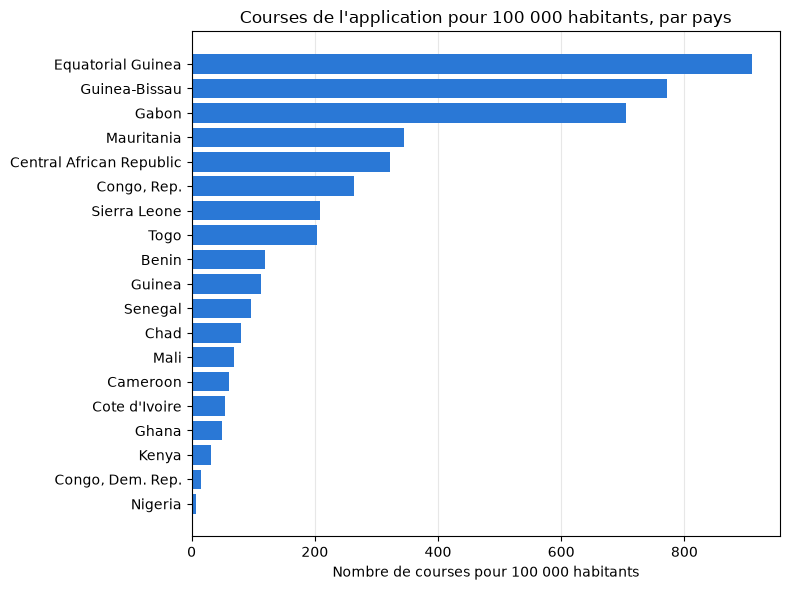

In [29]:
a_tracer = gold_livre.dropna(subset=["courses_pour_100k_hab"]).sort_values("courses_pour_100k_hab")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(a_tracer["nom_pays"], a_tracer["courses_pour_100k_hab"], color="#2a78d6")
ax.set_title("Courses de l'application pour 100 000 habitants, par pays")
ax.set_xlabel("Nombre de courses pour 100 000 habitants")
ax.grid(axis="x", alpha=0.3)   # lignes verticales légères pour lire les valeurs
ax.set_axisbelow(True)         # la grille derrière les barres
plt.tight_layout()             # évite que les noms de pays soient coupés
plt.show()

Lecture : les petits pays (Guinée équatoriale, Guinée-Bissau, Gabon) arrivent en tête, les grands pays (Nigeria, RD Congo) en bas. Avec des données réelles, ce graphique aiderait le comité à repérer les pays où l'application a encore une forte marge de croissance.

## 9. Exercices

### ✍️ Exercice 1 — Qui est où ?

Listez les codes pays présents **dans MongoDB mais pas dans PostgreSQL**, ceux présents **dans PostgreSQL mais pas dans MongoDB**, et ceux présents **dans les deux**.

*Indice : avec des ensembles Python, `a - b` donne les éléments de `a` absents de `b`, et `a & b` les éléments communs (l'intersection).*

In [30]:
# ✅ Solution
codes_mongo = set(activite["code_iso"])
codes_pg = set(eleves_par_pays["code_iso"])

print("Dans MongoDB seulement    :", sorted(codes_mongo - codes_pg))
print("Dans PostgreSQL seulement :", sorted(codes_pg - codes_mongo))
print("Dans les deux             :", sorted(codes_mongo & codes_pg))

Dans MongoDB seulement    : ['CD', 'CF', 'CG', 'CI', 'CM', 'GA', 'GH', 'GN', 'GQ', 'GW', 'KE', 'ML', 'MR', 'NG', 'SL', 'TD', 'TG']
Dans PostgreSQL seulement : ['FR']
Dans les deux             : ['BJ', 'SN']


Variante en SQL, dans DuckDB, pour l'une des trois listes (les pays de PostgreSQL absents de MongoDB) : `EXCEPT` garde les lignes de la première requête absentes de la seconde.

In [31]:
# ✅ Solution (variante SQL)
con.sql('''
    SELECT code_iso FROM bronze_pg_eleves
    EXCEPT
    SELECT code_iso FROM bronze_mongo_activite
''').df()

,code_iso
0,FR


### ✍️ Exercice 2 — Un export CSV pour Excel

Le directeur financier veut ouvrir le tableau dans **Excel** (version française). Exportez le tableau gold en CSV dans `../data/processed/`, de sorte qu'Excel l'ouvre correctement d'un double-clic.

*Indice : un Excel français attend le `;` comme séparateur de colonnes, la `,` comme séparateur décimal, et un encodage `utf-8-sig` (UTF-8 avec une signature, la « BOM ») pour afficher correctement les accents. Regardez les paramètres `sep`, `decimal` et `encoding` de `to_csv`.*

In [32]:
# ✅ Solution
fichier_csv = DOSSIER_PROCESSED / f"tableau_pays_gold_{date.today().isoformat()}.csv"
gold_livre.to_csv(fichier_csv, sep=";", decimal=",", index=False, encoding="utf-8-sig")

print("Fichier écrit :", fichier_csv)
lignes_du_fichier = fichier_csv.read_text(encoding="utf-8-sig").splitlines()
for ligne in lignes_du_fichier[:3]:   # les 3 premières lignes du fichier
    print(ligne)

Fichier écrit : ../data/processed/tableau_pays_gold_2026-10-07.csv
code_iso;nom_pays;population;annee_population;nb_courses;nb_utilisateurs;nb_eleves;courses_pour_100k_hab
GQ;Equatorial Guinea;1938431;2025;17634;1070;;909,7
GW;Guinea-Bissau;2249515;2025;17370;1057;;772,2


### ✍️ Exercice 3 — Vérifier l'idempotence en rechargeant deux fois

Dans une base DuckDB **en mémoire** (`duckdb.connect()` sans nom de fichier : elle disparaît à la fermeture, idéale pour une expérience), chargez **deux fois** le DataFrame `population` :
- dans une table `pop_insert` avec `INSERT INTO` ;
- dans une table `pop_replace` avec `CREATE OR REPLACE TABLE`.

Comptez les lignes après chaque chargement. Laquelle des deux méthodes est idempotente ?

*Indice : pour créer une table vide qui a les mêmes colonnes qu'un DataFrame : `CREATE TABLE pop_insert AS SELECT * FROM tableau_python LIMIT 0`.*

In [33]:
# ✅ Solution
con_test = duckdb.connect()   # base en mémoire, jetable
con_test.register("tableau_python", population)
con_test.execute("CREATE TABLE pop_insert AS SELECT * FROM tableau_python LIMIT 0")

for chargement in [1, 2]:
    con_test.execute("INSERT INTO pop_insert SELECT * FROM tableau_python")
    con_test.execute("CREATE OR REPLACE TABLE pop_replace AS SELECT * FROM tableau_python")
    nb_insert = con_test.sql("SELECT COUNT(*) FROM pop_insert").fetchone()[0]
    nb_replace = con_test.sql("SELECT COUNT(*) FROM pop_replace").fetchone()[0]
    print(f"Chargement n°{chargement} : INSERT INTO -> {nb_insert} lignes | CREATE OR REPLACE -> {nb_replace} lignes")

con_test.close()

Chargement n°1 : INSERT INTO -> 20 lignes | CREATE OR REPLACE -> 20 lignes
Chargement n°2 : INSERT INTO -> 40 lignes | CREATE OR REPLACE -> 20 lignes


`INSERT INTO` n'est **pas** idempotent : le 2ᵉ chargement double les lignes (chaque pays apparaît deux fois, et le contrôle d'unicité de la section 7 échouerait). `CREATE OR REPLACE` l'est. Autre méthode idempotente courante : supprimer d'abord ce qu'on va recharger (`DELETE FROM ... WHERE mois = ...`), puis insérer.

### ✍️ Exercice 4 — Ajouter le PIB par habitant

Le comité veut aussi voir la richesse de chaque pays. Ajoutez le **PIB par habitant en dollars** (indicateur Banque mondiale `NY.GDP.PCAP.CD`) en suivant les trois étapes ELT :
1. **E** : réutilisez la fonction `telecharger_banque_mondiale` et construisez un DataFrame `pib` (`code_iso`, `annee_pib`, `pib_par_hab_usd`) ;
2. **L** : chargez-le dans une table `bronze_bm_pib` (de façon idempotente !) ;
3. **T** : créez une table `gold_tableau_pays_pib` = la table gold + une colonne `pib_par_hab_usd` (arrondie à l'unité).

*Indice : `CAST(ROUND(x) AS INTEGER)` arrondit puis convertit en nombre entier.*

In [34]:
# ✅ Solution — E (extraire) : même fonction, autre indicateur
lignes_pib = telecharger_banque_mondiale(codes_iso, "NY.GDP.PCAP.CD")
lignes_pib_propres = []
for ligne in lignes_pib:
    lignes_pib_propres.append({
        "code_iso": ligne["country"]["id"],
        "annee_pib": int(ligne["date"]),
        "pib_par_hab_usd": ligne["value"],
    })
pib = pd.DataFrame(lignes_pib_propres)
pib.head(3)

Page 1/2 reçue : 10 lignes


Page 2/2 reçue : 10 lignes


,code_iso,annee_pib,pib_par_hab_usd
0,BJ,2025,1658.273127
1,CF,2025,556.131398
2,CI,2025,3050.102023


**L** (charger) : une nouvelle table bronze, toujours avec `CREATE OR REPLACE` pour rester idempotent.

In [35]:
# ✅ Solution — L (charger)
con.register("tableau_python", pib)
con.execute("CREATE OR REPLACE TABLE bronze_bm_pib AS SELECT * FROM tableau_python")
con.unregister("tableau_python")
print("bronze_bm_pib :", con.sql("SELECT COUNT(*) FROM bronze_bm_pib").fetchone()[0], "lignes")

bronze_bm_pib : 20 lignes


**T** (transformer) : la table gold, plus le PIB, accroché avec un `LEFT JOIN` sur le code ISO.

In [36]:
# ✅ Solution — T (transformer)
con.execute('''
    CREATE OR REPLACE TABLE gold_tableau_pays_pib AS
    SELECT g.*, CAST(ROUND(b.pib_par_hab_usd) AS INTEGER) AS pib_par_hab_usd
    FROM gold_tableau_pays AS g
    LEFT JOIN bronze_bm_pib AS b ON b.code_iso = g.code_iso
    ORDER BY g.courses_pour_100k_hab DESC NULLS LAST
''')
con.sql("SELECT code_iso, nom_pays, courses_pour_100k_hab, pib_par_hab_usd FROM gold_tableau_pays_pib").df()

,code_iso,nom_pays,courses_pour_100k_hab,pib_par_hab_usd
0,GQ,Equatorial Guinea,909.7,6615
1,GW,Guinea-Bissau,772.2,1124
2,GA,Gabon,704.8,8263
3,MR,Mauritania,345.3,2198
4,CF,Central African Republic,321.7,556
5,CG,"Congo, Rep.",263.9,2515
6,SL,Sierra Leone,208.0,846
7,TG,Togo,203.8,1384
8,BJ,Benin,118.8,1658
9,GN,Guinea,112.9,1877


> 💡 On a créé une **nouvelle** table gold au lieu de modifier `gold_tableau_pays` « sur elle-même » : la relancer donne toujours le même résultat. Et attention aux conclusions hâtives : deux colonnes qui varient ensemble ne prouvent pas que l'une explique l'autre (corrélation ≠ causalité), surtout sur des données synthétiques.

## 10. Fermer les connexions

On ferme toujours ce qu'on a ouvert :
- `client.close()` ferme la connexion MongoDB ;
- `engine.dispose()` ferme toutes les connexions PostgreSQL gardées en réserve par l'engine (sur une base partagée, chaque connexion ouverte occupe une place) ;
- `con.close()` libère le fichier DuckDB. Tant qu'un programme le garde ouvert en écriture, aucun autre (un autre notebook, DataGrip…) ne peut l'ouvrir : vous verriez l'erreur *Could not set lock on file*.

In [37]:
client.close()
engine.dispose()
con.close()
print("Connexions MongoDB, PostgreSQL et DuckDB fermées.")

Connexions MongoDB, PostgreSQL et DuckDB fermées.


## Récapitulatif

**Ce que vous avez fait**
- extrait un **résumé par pays** de trois sources : MongoDB (pipeline d'agrégation avec deux `$lookup`), PostgreSQL (deux `JOIN` + `GROUP BY`) et l'API Banque mondiale (pagination) ;
- constaté qu'une jointure sur le **nom** perd des pays **sans prévenir**, et joint sur le **code ISO** ;
- gardé tous les pays grâce à une **jointure externe** (liste complète des codes + `LEFT JOIN`) et interprété les `NULL` ;
- chargé des tables **bronze** dans DuckDB, construit une table **gold** en SQL (le « T » de ELT) et démontré l'**idempotence** ;
- contrôlé **unicité, complétude, réconciliation et fraîcheur** avant de livrer un **Parquet** et un graphique.

**Les réflexes à retenir**
- Laisser chaque source **calculer** (agrégation côté serveur) : on ne rapatrie que le nécessaire.
- Une clé de jointure doit être un **code normalisé** (ISO, identifiant), jamais un libellé.
- Toujours **compter les lignes** avant et après une jointure : une jointure interne peut faire disparaître des données en silence.
- `NULL` ≠ 0 : un vide peut vouloir dire « non couvert par la source ».
- Un pipeline doit être **idempotent** (`CREATE OR REPLACE`, ou supprimer puis réinsérer) : on peut le relancer sans crainte.
- **Contrôler avant de livrer**, et noter la date d'extraction de chaque donnée.

## Pour aller plus loin

- **Une vraie couche silver** : créez une table de référence des pays (code ISO2, code ISO3, nom français, nom anglais, devise) et utilisez-la partout. C'est ce qu'on appelle un **référentiel** (ou *données de référence*).
- **Ouvrir la base DuckDB dans DataGrip** (pilote DuckDB, fichier `data/tp_integration.duckdb`) et rejouer les requêtes de la section 6 (exécutez d'abord la section 10 du notebook, qui ferme la connexion DuckDB et libère le verrou).
- **Automatiser** : transformer ce notebook en script Python lancé chaque mois (planificateur `cron`, Airflow, Dagster…), avec une extraction **incrémentale** (notebooks 02 et 03).
- **Outils de transformation** : dbt permet d'écrire les tables silver/gold en SQL, de les versionner avec Git et de déclarer des tests de qualité (`unique`, `not_null`) comme ceux de la section 7.